# POSTTEST 3 — SUPERVISED LEARNING
## Tokyo 2020 Olympic Games

**Supervised Learning dengan tugas regresi** untuk memprediksi `Rank` negara/entitas pada Olimpiade Tokyo 2020.

**Target (Y):** `Rank`

**Variabel X:**
- `Gold Medal`
- `Silver Medal`
- `Bronze Medal`

`Total` tidak digunakan sebagai X karena merupakan penjumlahan dari Gold Medal, Silver Medal, dan Bronze Medal sehingga dapat memberikan informasi yang berulang.

Karena target `Rank` berupa nilai numerik, pendekatan yang digunakan adalah **regresi**.

## 1. Import Library

Pandas dan NumPy digunakan untuk pengolahan data. Matplotlib dan Seaborn digunakan untuk visualisasi. Scikit-learn digunakan untuk pembagian data, standardisasi, model regresi, dan evaluasi.

In [5]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

## 2. Memuat Dataset

Dataset yang digunakan adalah `medals_total.csv`.

Jika file sudah tersedia di folder kerja Colab, notebook akan langsung menggunakannya. Jika belum, upload ZIP Tokyo 2020 yang berisi `medals_total.csv`.

In [6]:
# Mencari dataset yang sudah tersedia
if os.path.exists('medals_total.csv'):
    csv_path = 'medals_total.csv'
    print('medals_total.csv ditemukan.')
elif os.path.exists('dataset_tokyo2020/medals_total.csv'):
    csv_path = 'dataset_tokyo2020/medals_total.csv'
    print('medals_total.csv ditemukan di dataset_tokyo2020.')
else:
    print('Dataset belum ditemukan. Silakan upload ZIP Tokyo 2020.')
    from google.colab import files
    uploaded = files.upload()
    zip_file = list(uploaded.keys())[0]

    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('dataset_tokyo2020')

    csv_path = 'dataset_tokyo2020/medals_total.csv'
    print('ZIP berhasil diekstrak.')

df = pd.read_csv(csv_path)

print('Ukuran dataset:', df.shape)
df.head()

medals_total.csv ditemukan di dataset_tokyo2020.
Ukuran dataset: (93, 7)


,Rank,Country Code,Gold Medal,Silver Medal,Bronze Medal,Total,Country
0,1,USA,39,41,33,113,United States of America
1,2,CHN,38,32,18,88,People's Republic of China
2,3,JPN,27,14,17,58,Japan
3,4,GBR,22,21,22,65,Great Britain
4,5,ROC,20,28,23,71,ROC


## 3. Menentukan Variabel X dan Target Y

Digunakan minimal dua variabel X sesuai ketentuan. Pada notebook ini digunakan tiga variabel X, yaitu jumlah medali emas, perak, dan perunggu.

Target Y adalah `Rank`.

`Total` sengaja tidak digunakan sebagai X karena merupakan hasil penjumlahan langsung dari tiga variabel medali yang digunakan.

In [7]:
X = df[['Gold Medal', 'Silver Medal', 'Bronze Medal']]
y = df['Rank']

print('Variabel X:')
print(X.columns.tolist())

print('\nTarget Y: Rank')
print('Jumlah variabel X:', X.shape[1])
print('Jumlah data:', len(df))

Variabel X:
['Gold Medal', 'Silver Medal', 'Bronze Medal']

Target Y: Rank
Jumlah variabel X: 3
Jumlah data: 93


## 4. Membagi Data Training dan Testing

Dataset dibagi menjadi 80% data training dan 20% data testing.

Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengetahui kemampuan model pada data yang belum digunakan saat proses training.

`random_state=42` digunakan agar pembagian data dapat direproduksi.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print('Data training:', len(X_train))
print('Data testing :', len(X_test))

Data training: 74
Data testing : 19


## 5. Standardisasi Variabel X

Standardisasi dilakukan menggunakan `StandardScaler`.

Scaler hanya di-fit pada data training untuk menghindari data leakage. Setelah itu, scaler yang sama digunakan untuk mengubah data testing.

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('X_train shape:', X_train_scaled.shape)
print('X_test shape :', X_test_scaled.shape)

X_train shape: (74, 3)
X_test shape : (19, 3)


# MODEL 1 — LINEAR REGRESSION

## 6. Training Model

Linear Regression digunakan sebagai model regresi pertama untuk mempelajari hubungan antara jumlah medali dan Rank.

In [10]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

print('Linear Regression berhasil dilatih.')

Linear Regression berhasil dilatih.


## 7. Evaluasi Linear Regression

Digunakan tiga metrik:

- **MAE:** rata-rata kesalahan absolut. Semakin kecil semakin baik.
- **RMSE:** mengukur kesalahan dengan memberikan penalti lebih besar pada kesalahan yang besar. Semakin kecil semakin baik.
- **R²:** mengukur proporsi variasi target yang dapat dijelaskan model. Semakin mendekati 1 semakin baik.

In [11]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print('=== Linear Regression ===')
print('MAE :', round(mae_linear, 2))
print('RMSE:', round(rmse_linear, 2))
print('R²  :', round(r2_linear, 2))

=== Linear Regression ===
MAE : 20.95
RMSE: 25.04
R²  : 0.06


# MODEL 2 — RANDOM FOREST REGRESSOR

## 8. Training Model

Random Forest Regressor digunakan sebagai model kedua. Model ini merupakan ensemble dari beberapa decision tree dan dapat menangkap pola yang tidak harus linear.

In [12]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print('Random Forest Regressor berhasil dilatih.')

Random Forest Regressor berhasil dilatih.


## 9. Evaluasi Random Forest

Model kedua dievaluasi menggunakan MAE, RMSE, dan R² yang sama agar hasil kedua model dapat dibandingkan secara langsung.

In [13]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print('=== Random Forest Regressor ===')
print('MAE :', round(mae_rf, 2))
print('RMSE:', round(rmse_rf, 2))
print('R²  :', round(r2_rf, 2))

=== Random Forest Regressor ===
MAE : 1.18
RMSE: 1.49
R²  : 1.0


## 10. Perbandingan Model

MAE dan RMSE yang lebih kecil menunjukkan kesalahan prediksi yang lebih kecil. R² yang lebih besar menunjukkan bahwa model menjelaskan variasi Rank dengan lebih baik.

Nilai pada tabel berikut merupakan hasil evaluasi pada data testing.

In [14]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [mae_linear, mae_rf],
    'RMSE': [rmse_linear, rmse_rf],
    'R2': [r2_linear, r2_rf]
})

comparison.round(2)

,Model,MAE,RMSE,R2
0,Linear Regression,20.95,25.04,0.06
1,Random Forest Regressor,1.18,1.49,1.00


## 11. Grafik Prediksi pada Data Testing

Grafik membandingkan Rank aktual dengan Rank hasil prediksi dari kedua model.

Garis diagonal merupakan kondisi ideal ketika nilai aktual dan prediksi sama. Semakin dekat titik ke garis tersebut, semakin dekat prediksi dengan nilai sebenarnya.

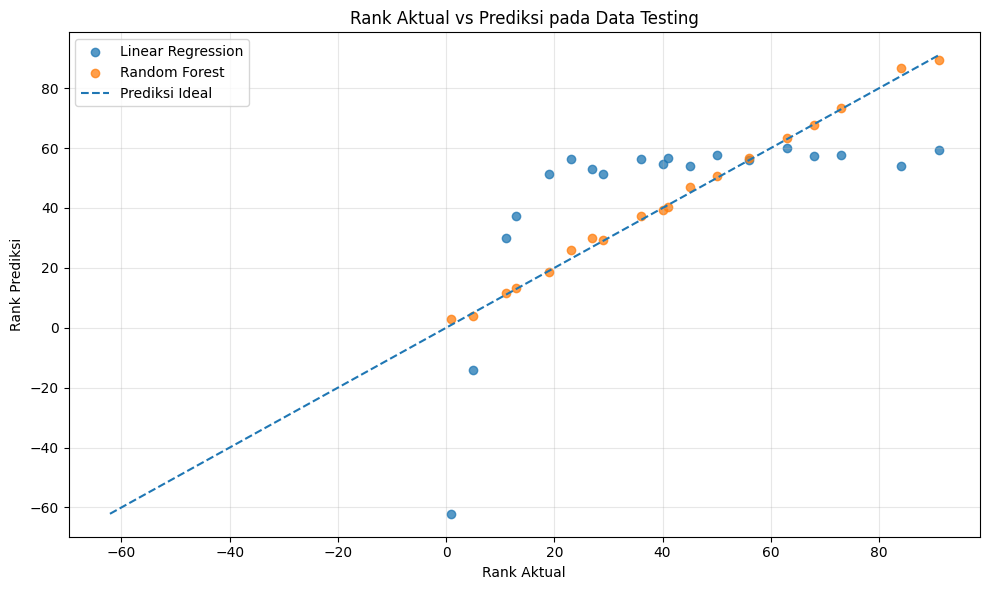

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test, y_pred_linear,
    alpha=0.75,
    label='Linear Regression'
)

plt.scatter(
    y_test, y_pred_rf,
    alpha=0.75,
    label='Random Forest'
)

min_value = min(y_test.min(), y_pred_linear.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_linear.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--',
    label='Prediksi Ideal'
)

plt.xlabel('Rank Aktual')
plt.ylabel('Rank Prediksi')
plt.title('Rank Aktual vs Prediksi pada Data Testing')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Grafik Detail Random Forest

Grafik berikut menunjukkan Rank aktual dan Rank hasil prediksi Random Forest untuk setiap data testing. Grafik ini membantu melihat perbedaan prediksi secara lebih rinci.

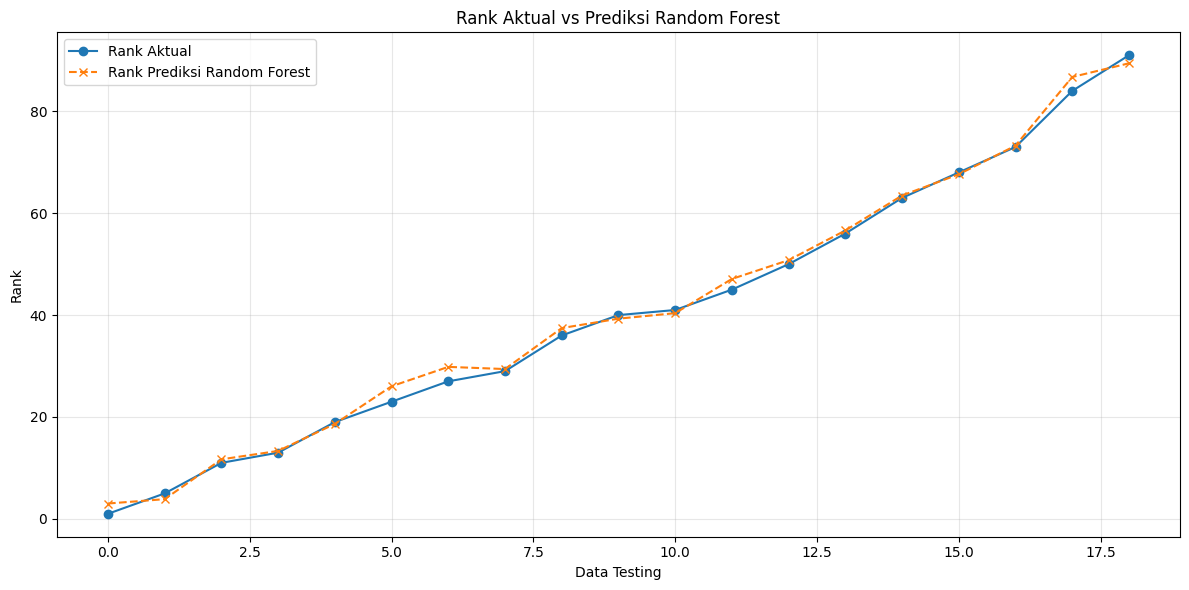

In [16]:
plot_df = pd.DataFrame({
    'Rank Aktual': y_test.values,
    'Rank Prediksi': y_pred_rf
}).sort_values('Rank Aktual').reset_index(drop=True)

plt.figure(figsize=(12, 6))

plt.plot(
    plot_df.index,
    plot_df['Rank Aktual'],
    marker='o',
    label='Rank Aktual'
)

plt.plot(
    plot_df.index,
    plot_df['Rank Prediksi'],
    marker='x',
    linestyle='--',
    label='Rank Prediksi Random Forest'
)

plt.xlabel('Data Testing')
plt.ylabel('Rank')
plt.title('Rank Aktual vs Prediksi Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Tabel Hasil Prediksi Data Testing

Tabel berikut menampilkan negara pada data testing, Rank aktual, Rank prediksi Random Forest, dan error absolut.

In [17]:
prediction_result = pd.DataFrame({
    'Country': df.loc[y_test.index, 'Country'].values,
    'Rank Aktual': y_test.values,
    'Rank Prediksi': np.round(y_pred_rf, 2)
})

prediction_result['Error Absolut'] = (
    prediction_result['Rank Aktual'] -
    prediction_result['Rank Prediksi']
).abs()

prediction_result.sort_values('Rank Aktual').reset_index(drop=True)

,Country,Rank Aktual,Rank Prediksi,Error Absolut
0,United States of America,1,3.02,2.02
1,ROC,5,3.87,1.13
2,Canada,11,11.69,0.69
3,New Zealand,13,13.34,0.34
4,Kenya,19,18.64,0.36
5,Sweden,23,26.03,3.03
6,Islamic Republic of Iran,27,29.84,2.84
7,Belgium,29,29.41,0.41
8,Greece,36,37.45,1.45
9,Israel,40,39.30,0.70


## 14. Feature Importance Random Forest

Feature importance menunjukkan kontribusi relatif setiap variabel X dalam proses prediksi Random Forest.

Nilai importance bukan berarti hubungan sebab-akibat; nilai tersebut merupakan ukuran yang diberikan oleh model berdasarkan penggunaannya dalam pembentukan prediksi.

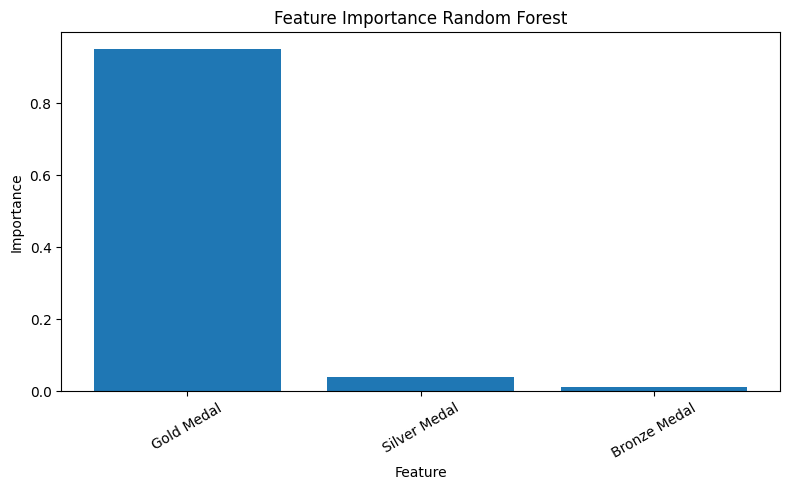

,Feature,Importance
0,Gold Medal,0.95
1,Silver Medal,0.04
2,Bronze Medal,0.01


In [18]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance Random Forest')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

importance_df

## 15. Analisis Hasil Evaluasi

Interpretasi hasil evaluasi dilakukan berdasarkan nilai yang muncul setelah notebook dijalankan.

- MAE menunjukkan rata-rata jarak Rank prediksi dari Rank aktual.
- RMSE memberikan penalti lebih besar terhadap kesalahan prediksi yang besar.
- R² menunjukkan seberapa besar variasi Rank yang dapat dijelaskan oleh model.

Performa model dapat dipengaruhi oleh ukuran dataset yang relatif kecil serta hubungan antara jumlah medali dan Rank. Rank juga merupakan hasil pemeringkatan sehingga hubungan antara jumlah medali dan Rank tidak selalu berbentuk hubungan linear sederhana.

Jika terdapat perbedaan hasil antara Linear Regression dan Random Forest, perbedaan tersebut menunjukkan bahwa kedua model menangkap pola data dengan cara yang berbeda.

# KESIMPULAN

Notebook ini menggunakan pendekatan **Supervised Learning — Regresi** untuk memprediksi `Rank` pada dataset Tokyo 2020 Olympic Games.

Terdapat tiga variabel X, yaitu `Gold Medal`, `Silver Medal`, dan `Bronze Medal`, serta satu target Y yaitu `Rank`.

Dua algoritma digunakan:
1. Linear Regression
2. Random Forest Regressor

Evaluasi dilakukan menggunakan MAE, RMSE, dan R². Selain tabel evaluasi, dibuat grafik perbandingan Rank aktual dan Rank prediksi pada dataset testing serta feature importance Random Forest.

Kesimpulan mengenai model yang memberikan hasil evaluasi lebih baik harus didasarkan pada nilai MAE, RMSE, dan R² yang muncul setelah notebook dijalankan. Secara umum, MAE dan RMSE yang lebih rendah serta R² yang lebih tinggi menunjukkan performa regresi yang lebih baik.

Notebook ini memenuhi ketentuan Supervised Learning: minimal dua variabel X, minimal satu algoritma, minimal dua metrik evaluasi, grafik prediksi pada data testing, penjelasan Markdown pada setiap langkah, serta kesimpulan akhir.